In [1]:
import warnings;
warnings.simplefilter('ignore')
from dcr import *

In [2]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (16,9)
plt.rcParams.update({'font.size': 16})

In [3]:
from dcr import *  

data, _, _, _, _, _, _ = dataprep(data)

In [4]:
data.loc[:,'CCM']= (data.balance_time - data.balance_scheduled_time)/ data.property_orig_time

            CCM
count  59001.00
mean       0.02
std        0.13
min       -0.89
25%        0.00
50%        0.01
75%        0.03
max        4.86


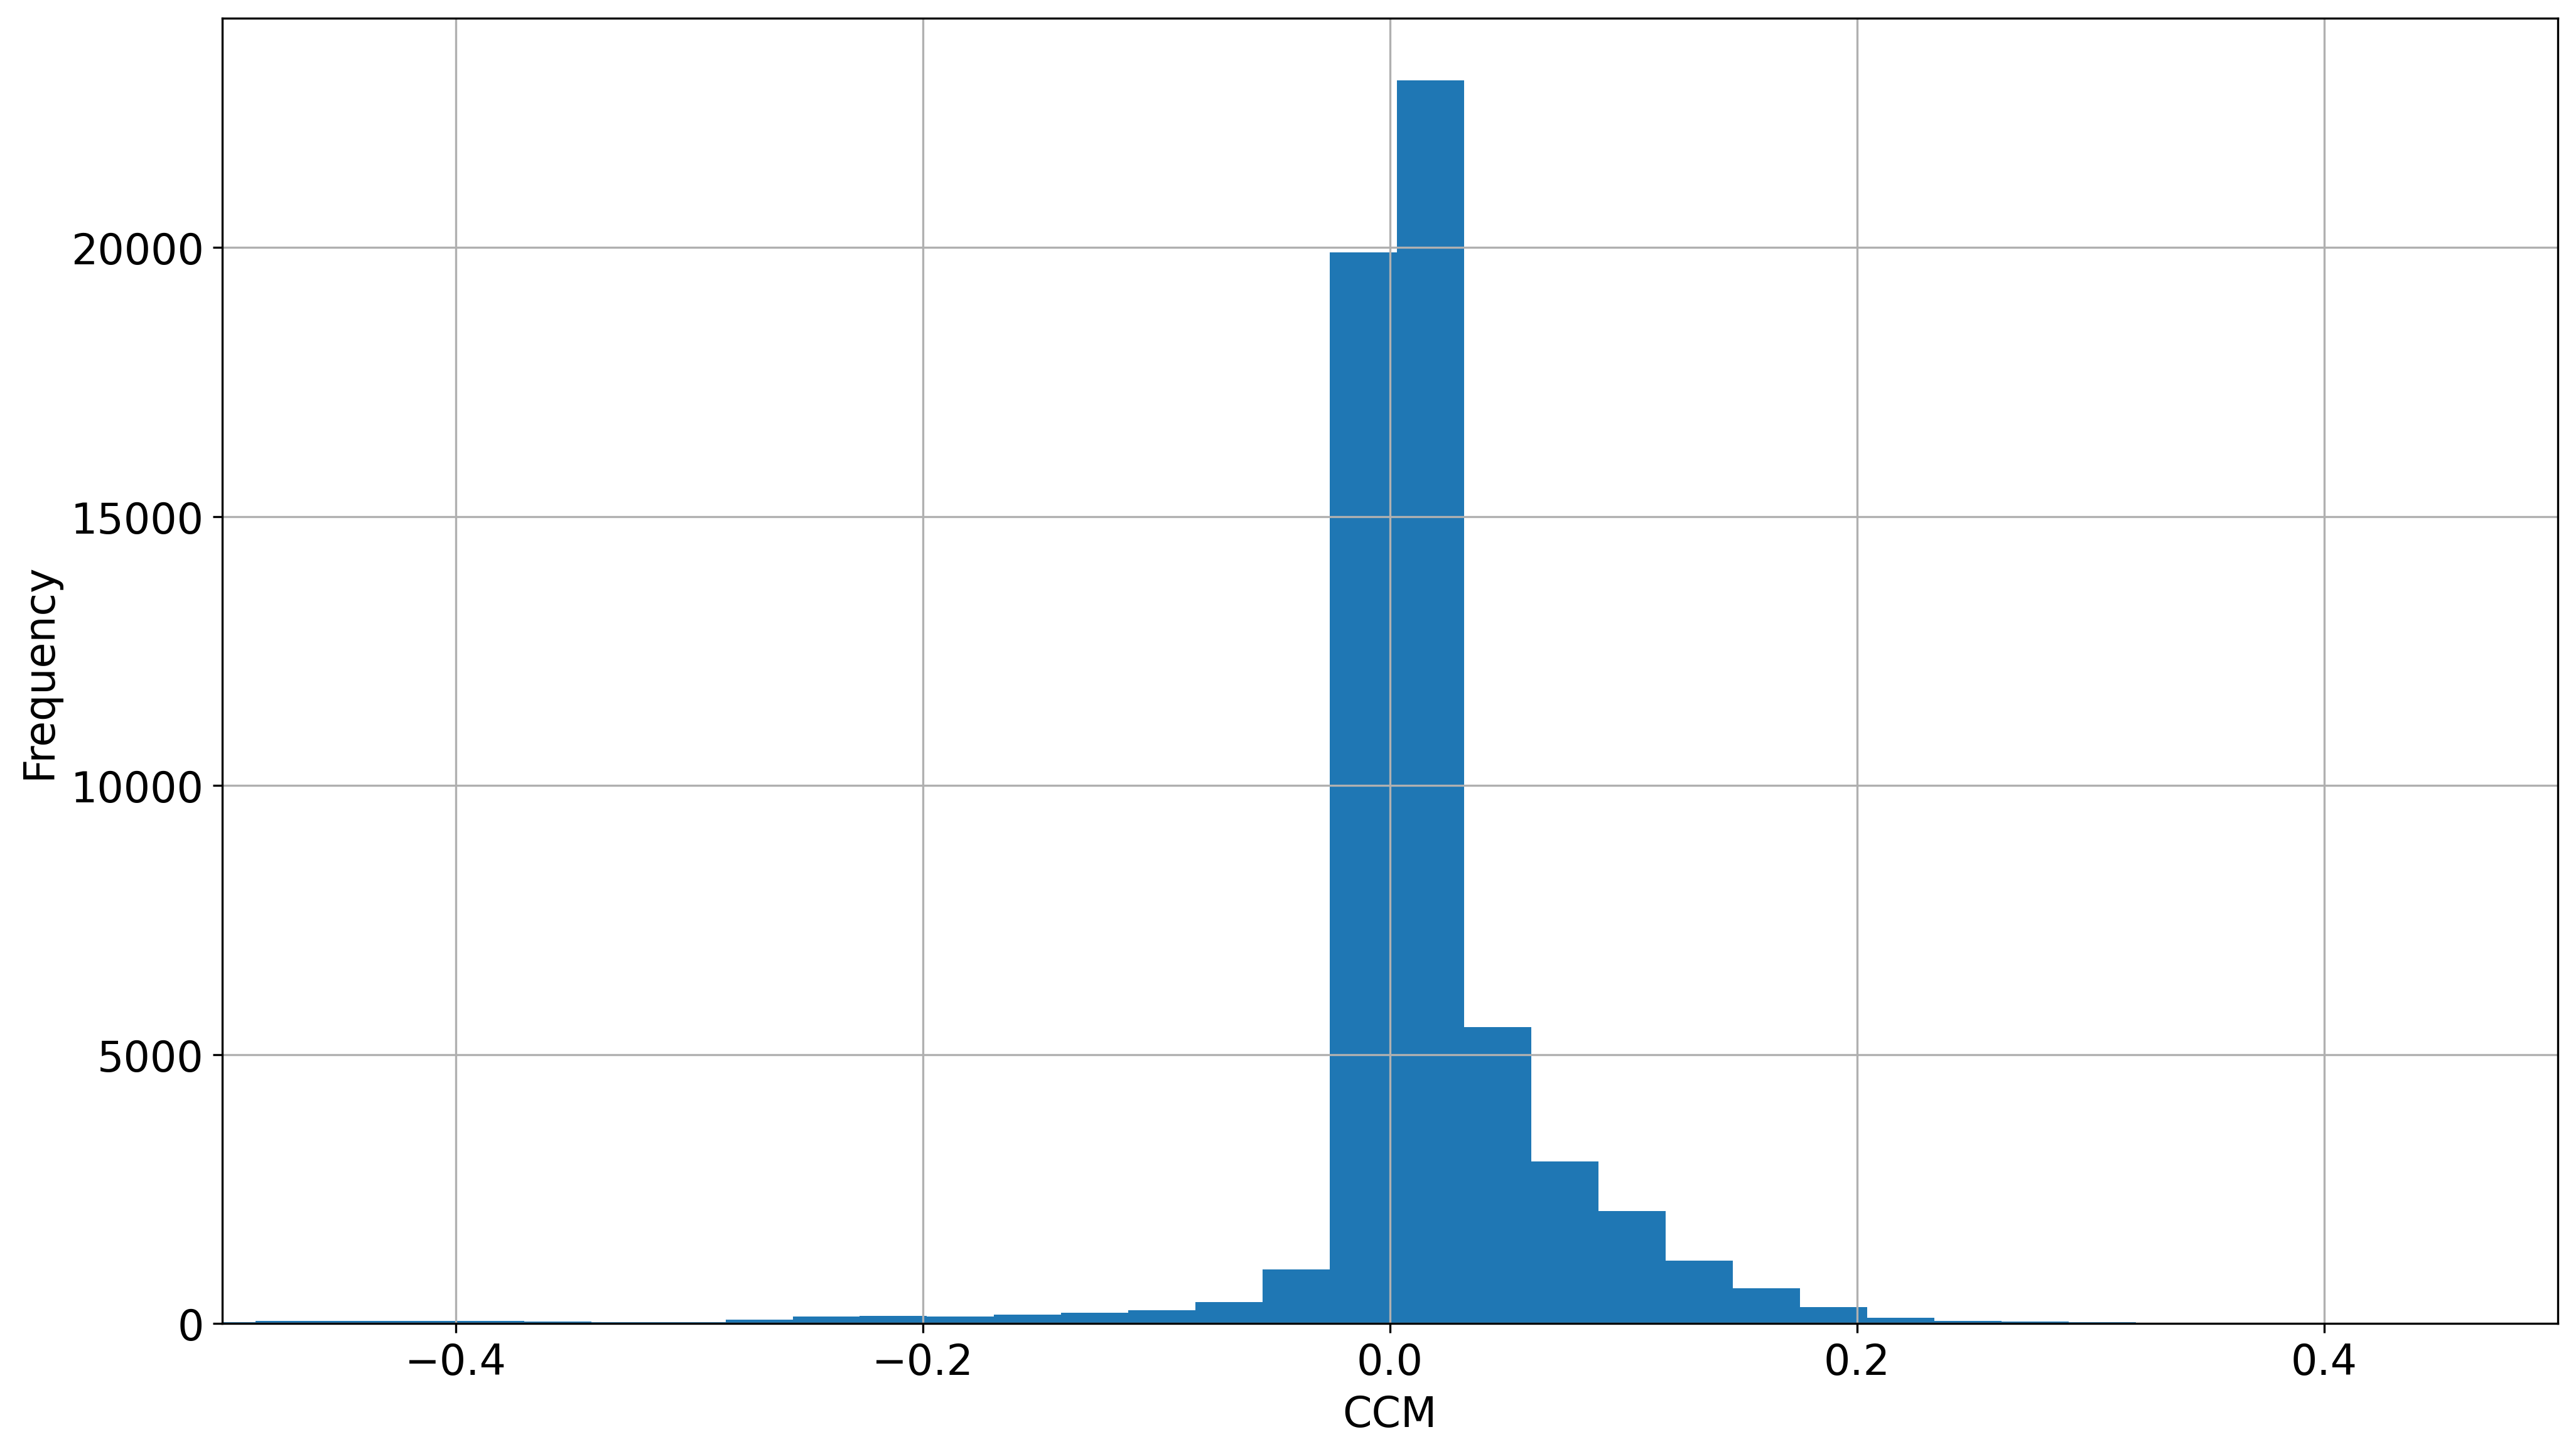

In [5]:
print(data[['CCM']].describe().round(decimals=2))  
data.CCM.hist(bins=200) 
xlim((-0.5, 0.5)) 
plt.xlabel('CCM') 
plt.ylabel('Frequency')  
plt.show()

In [6]:
model_ols_ccm = smf.ols(formula='CCM ~ equity_time + interest_rate_time + FICO_orig_time + gdp_time', data=data).fit()  
print(model_ols_ccm.summary())

                            OLS Regression Results                            
Dep. Variable:                    CCM   R-squared:                       0.413
Model:                            OLS   Adj. R-squared:                  0.413
Method:                 Least Squares   F-statistic:                 1.038e+04
Date:                Sun, 17 Aug 2025   Prob (F-statistic):               0.00
Time:                        18:39:34   Log-Likelihood:                 54248.
No. Observations:               59001   AIC:                        -1.085e+05
Df Residuals:                   58996   BIC:                        -1.084e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0733      0

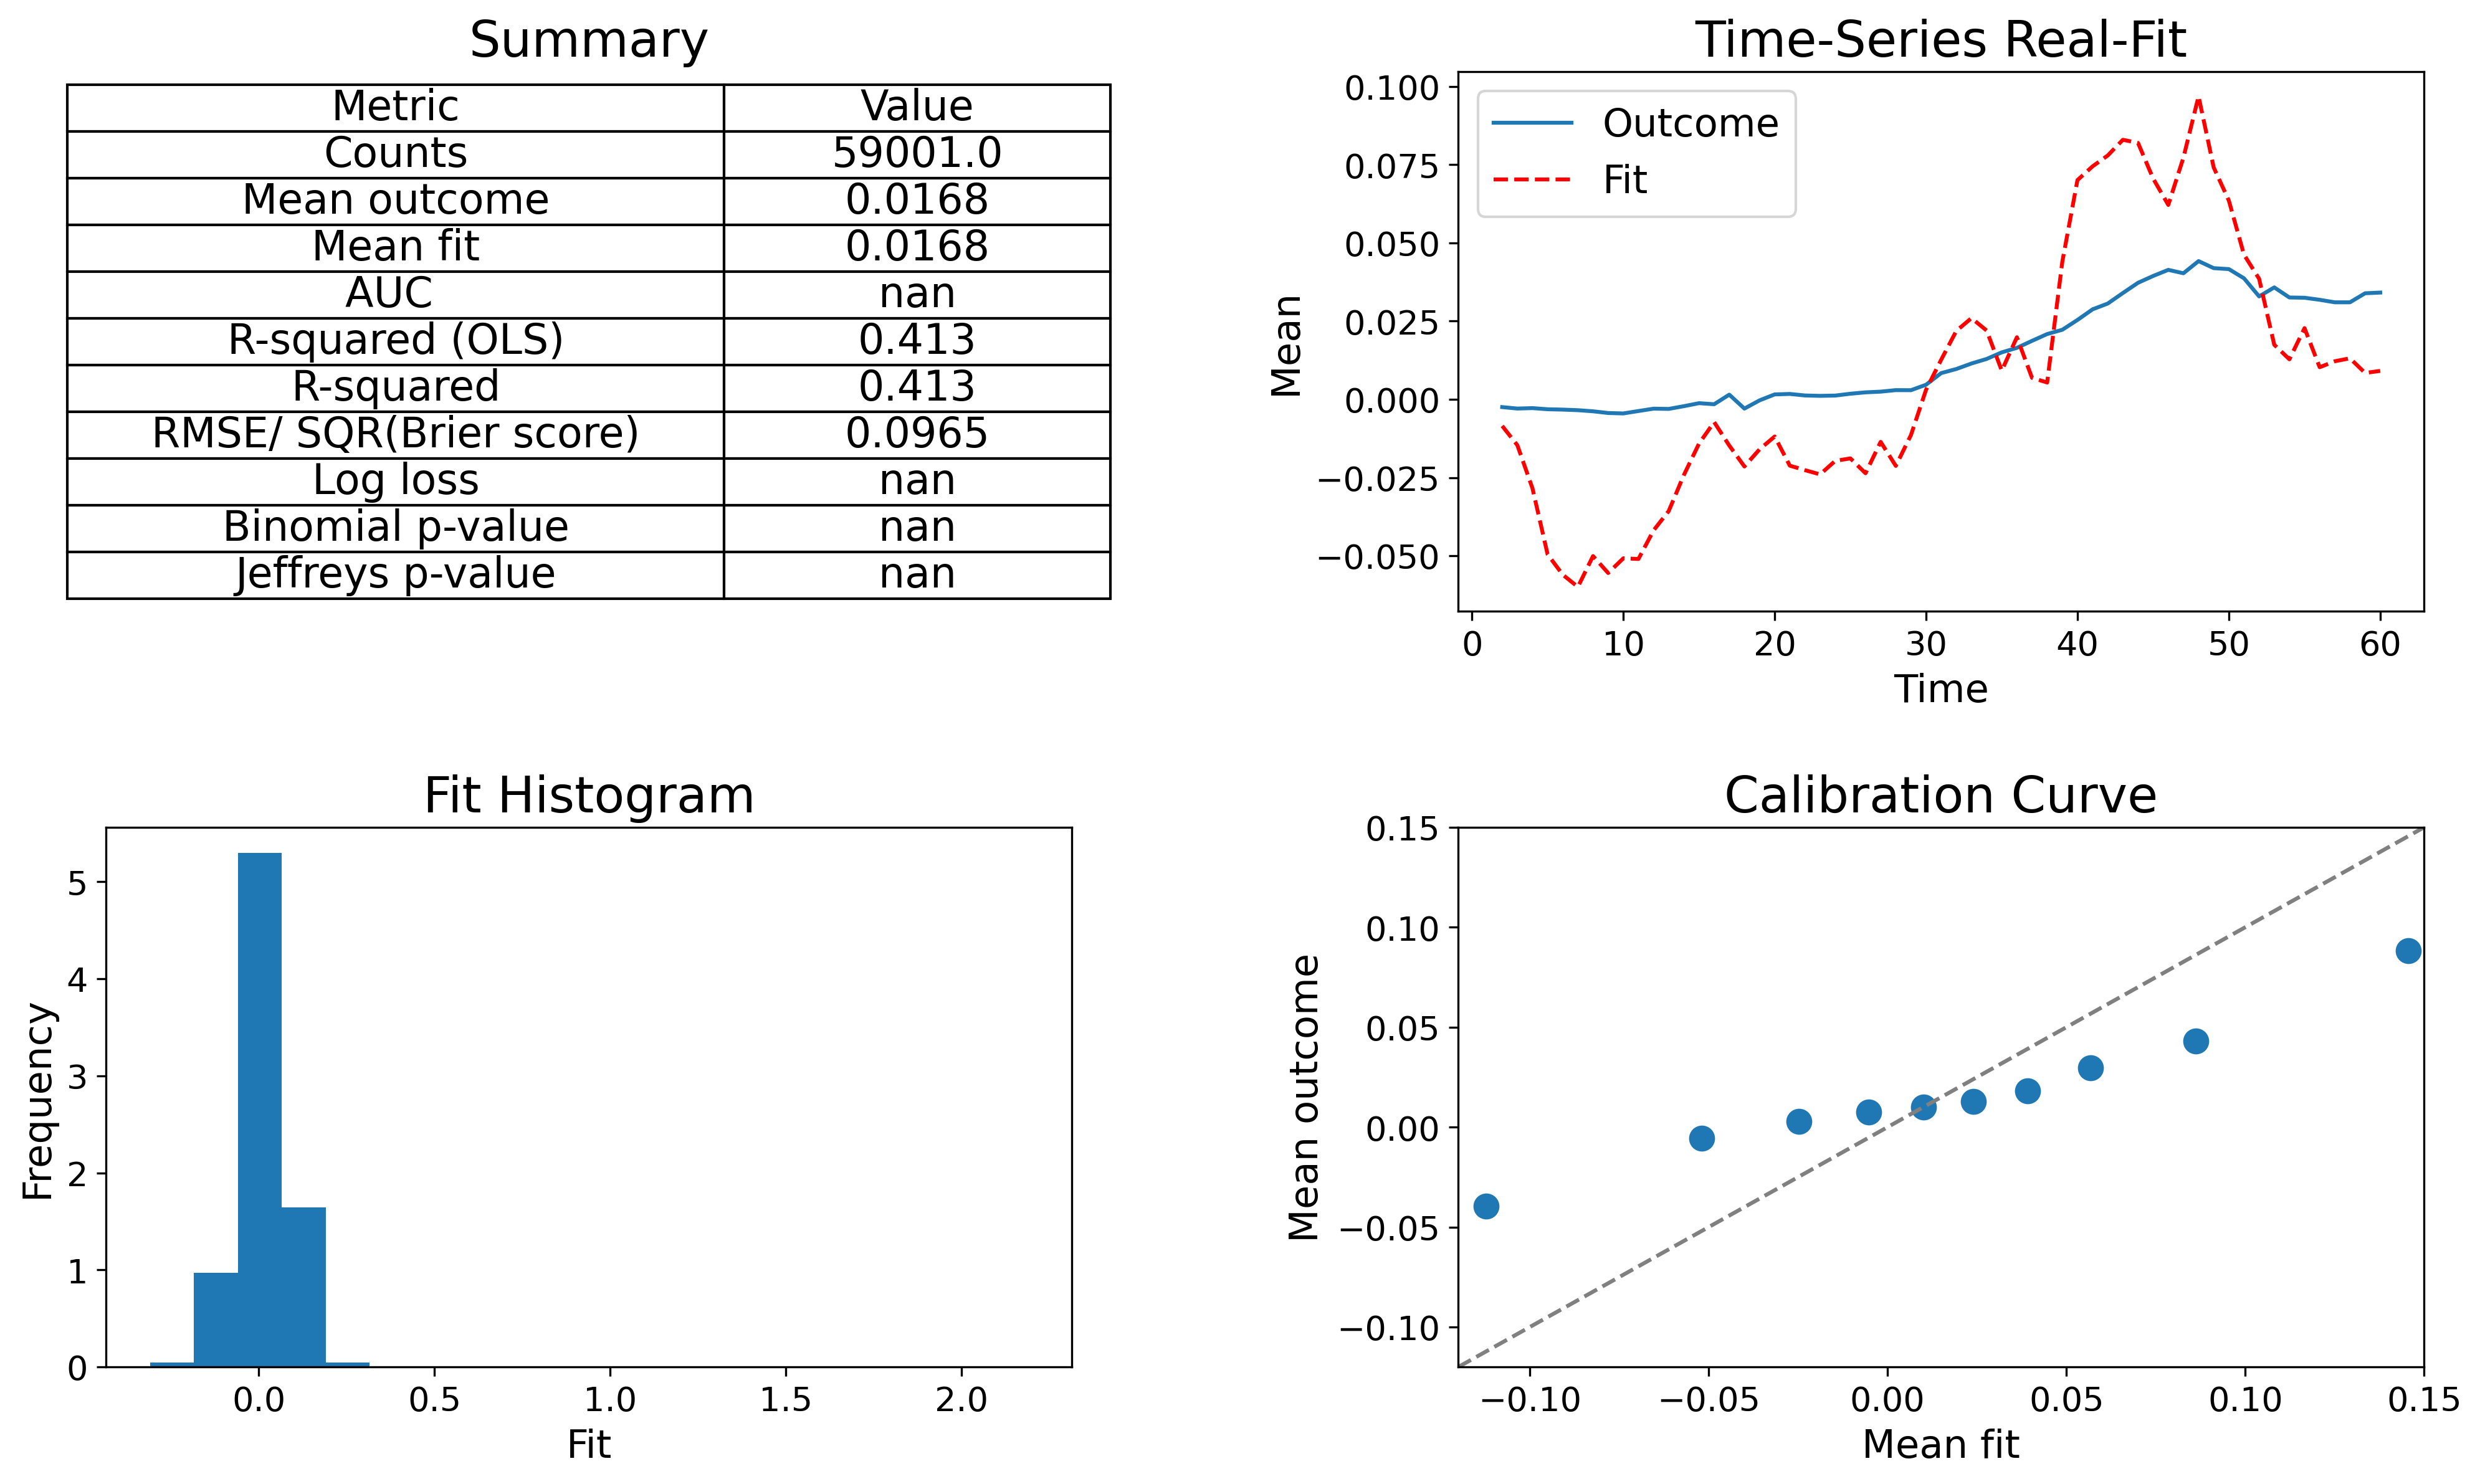

In [7]:
fittedvalues = pd.DataFrame(model_ols_ccm.fittedvalues,columns = ['CCM_fit']) 

data2 = pd.merge(data, fittedvalues, right_index=True, left_index=True)  

validation(data2.CCM_fit, data2.CCM, data2.time, continuous=True) 

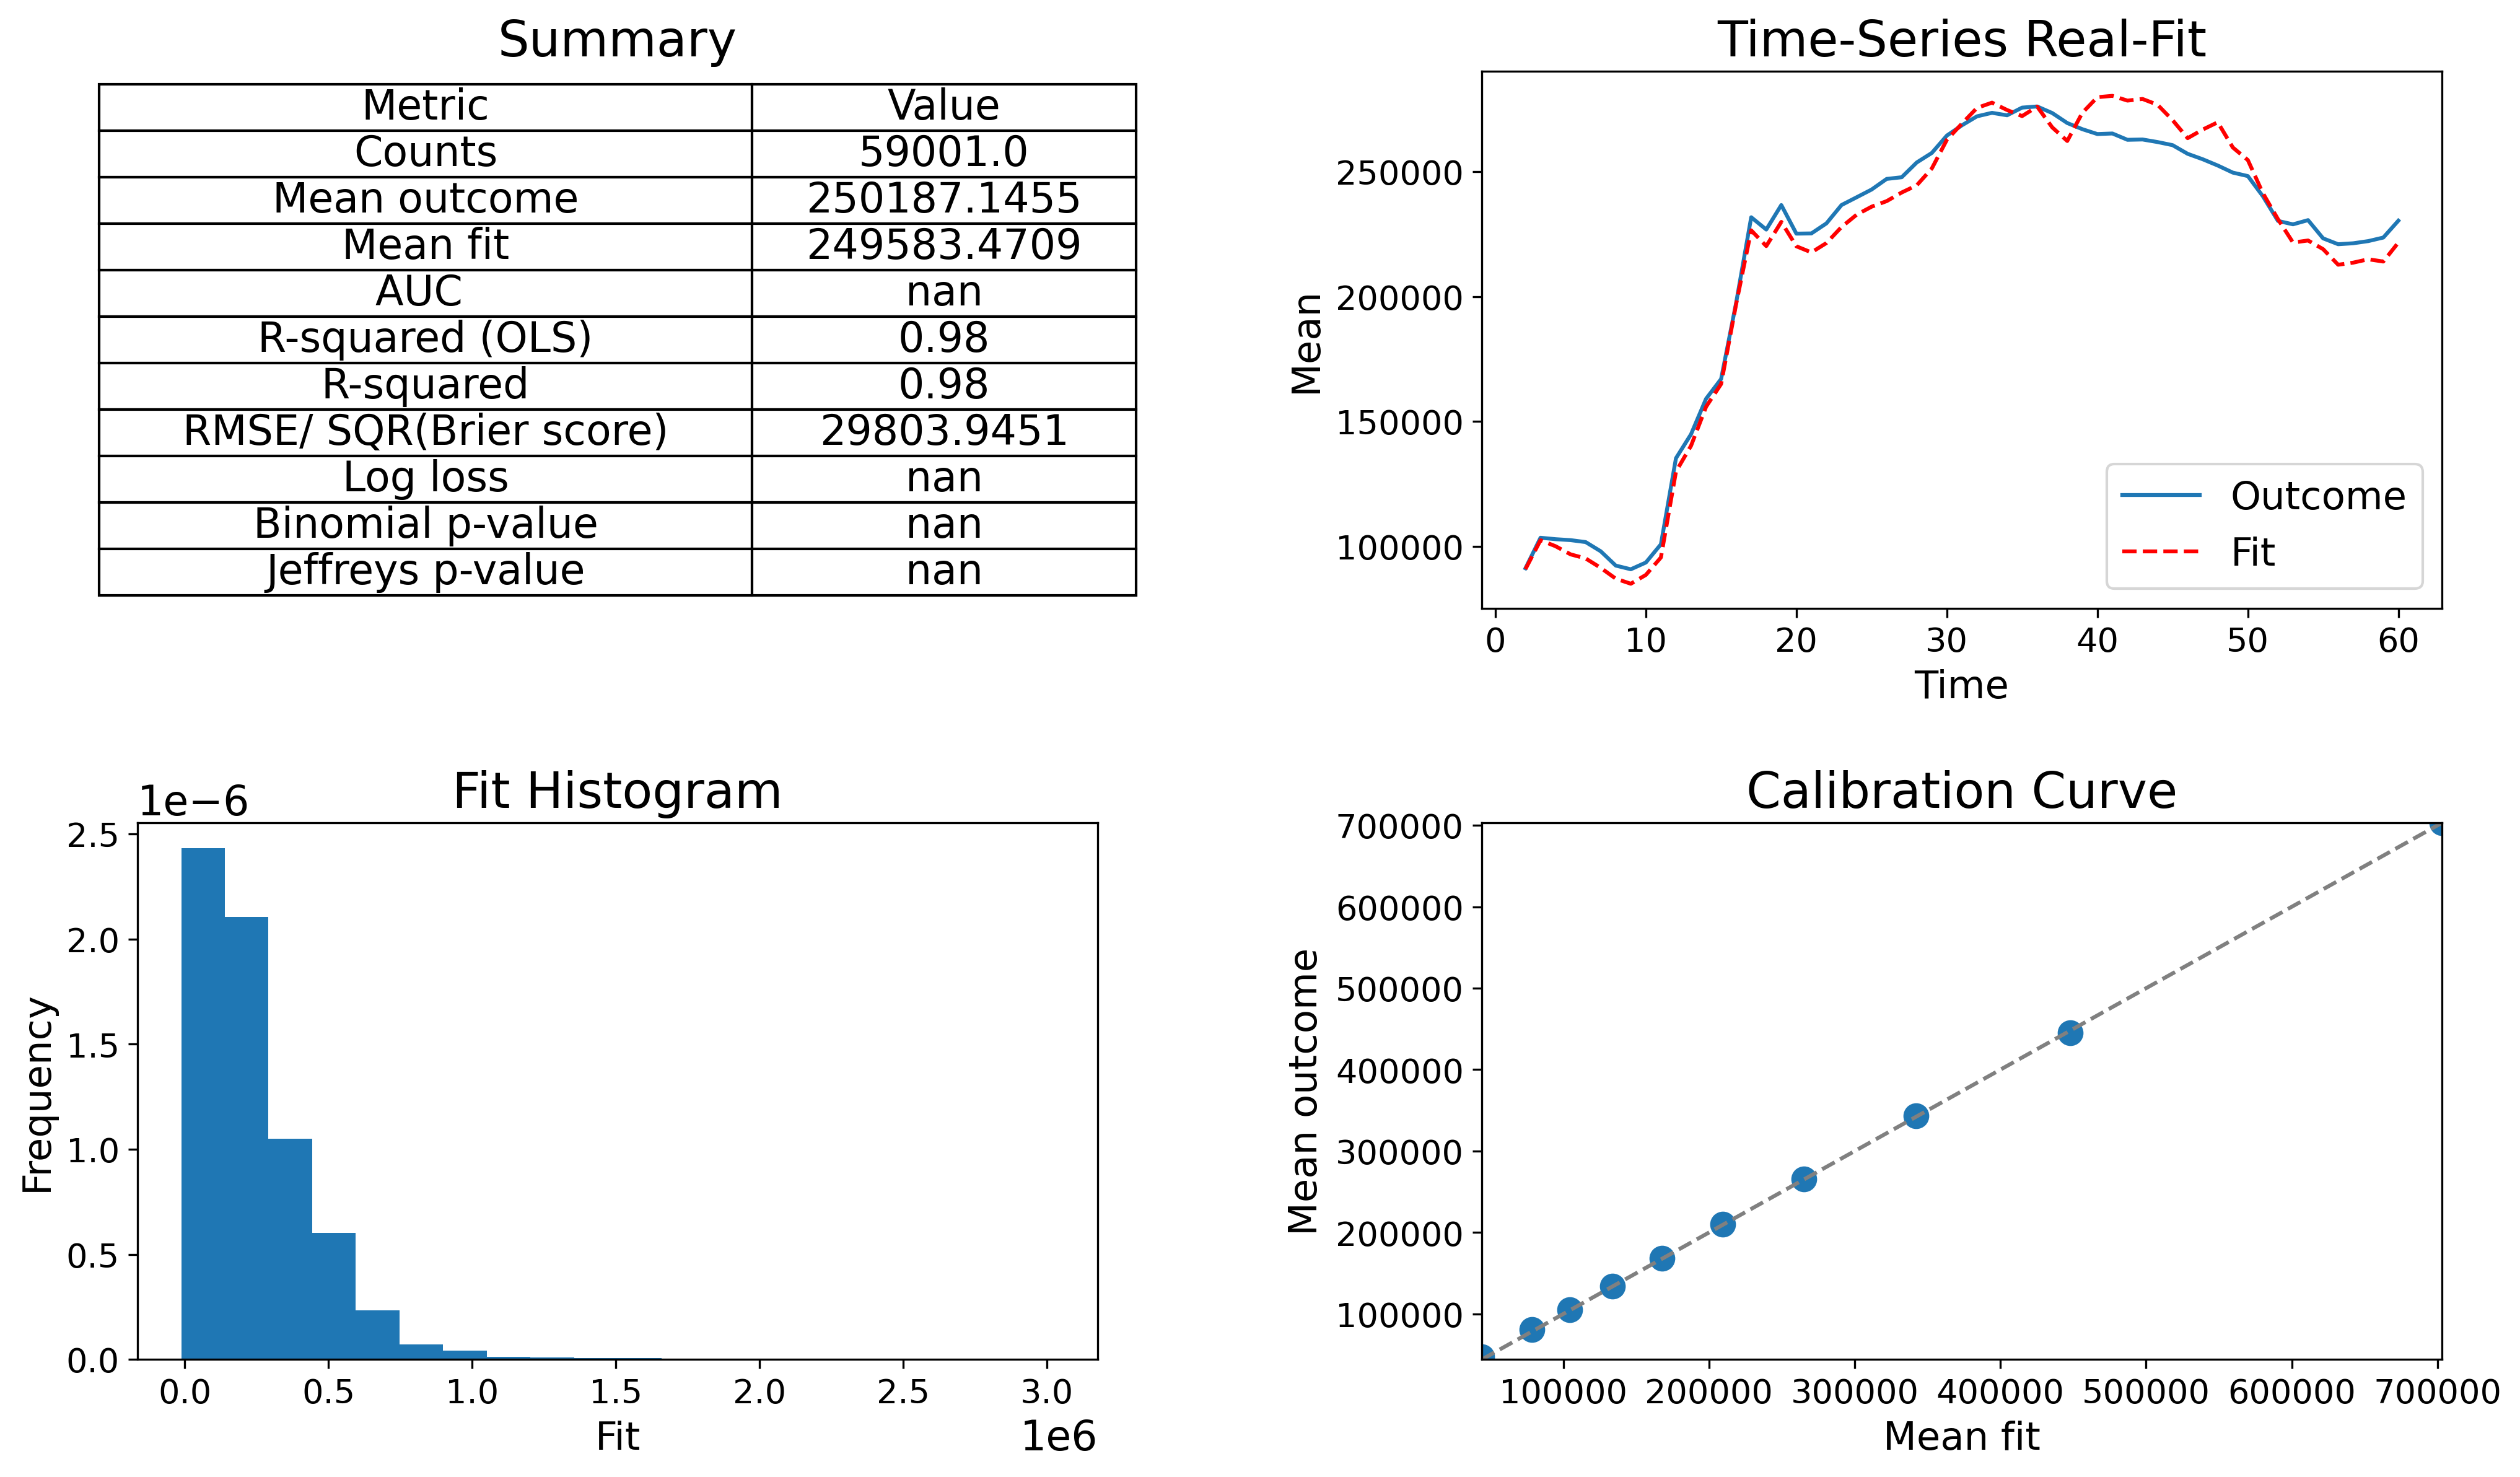

In [8]:
data2.loc[:,'exposure_fit'] = data2.loc[:,'balance_scheduled_time'] + data2.loc[:,'CCM_fit'] * data2.loc[:,'property_orig_time']  

validation(data2.exposure_fit, data2.balance_time, data2.time, continuous=True) 

In [9]:
data = data.sort_values(by=['id', 'time']) 
data.loc[:,'balance_time_1'] = data.groupby(['id'])['balance_time'].shift(1) 

data.loc[:,'ulimit'] = data.loc[:,'balance_orig_time']-data.loc[:,'balance_time_1']  
data.loc[data['ulimit'] <= 1000, 'ulimit'] = 10000  
data.loc[:,'limit'] = data.loc[:,'balance_orig_time']  
data.loc[data['limit'] <= 1000, 'limit'] = 10000  
data.loc[:,'CCF'] = (data.loc[:,'balance_time']-data.loc[:,'balance_time_1'])/data.loc[:,'ulimit'] 
data.loc[:,'CEQ'] = (data.loc[:,'balance_time']-data.loc[:,'balance_time_1'])/data.loc[:,'limit']  
data.loc[:,'LCF'] = data.loc[:,'balance_time']/data.loc[:,'limit'] 
data.loc[:,'UACF'] = data.loc[:,'balance_time']/data.loc[:,'balance_time_1']  

data_default = data.query('default_time == 1')  
data_default = data_default.dropna(subset=['CCF','CEQ','LCF','UACF']) 
print(data_default[['CCF','CEQ','LCF','UACF']].describe().round(decimals=2)) 

           CCF      CEQ      LCF     UACF
count  1402.00  1402.00  1402.00  1402.00
mean     -0.01    -0.00     0.99     1.00
std       0.55     0.01     0.05     0.01
min     -12.55    -0.21     0.51     0.79
25%      -0.03    -0.00     0.98     1.00
50%       0.00     0.00     1.00     1.00
75%       0.00     0.00     1.00     1.00
max      15.71     0.10     1.23     1.10


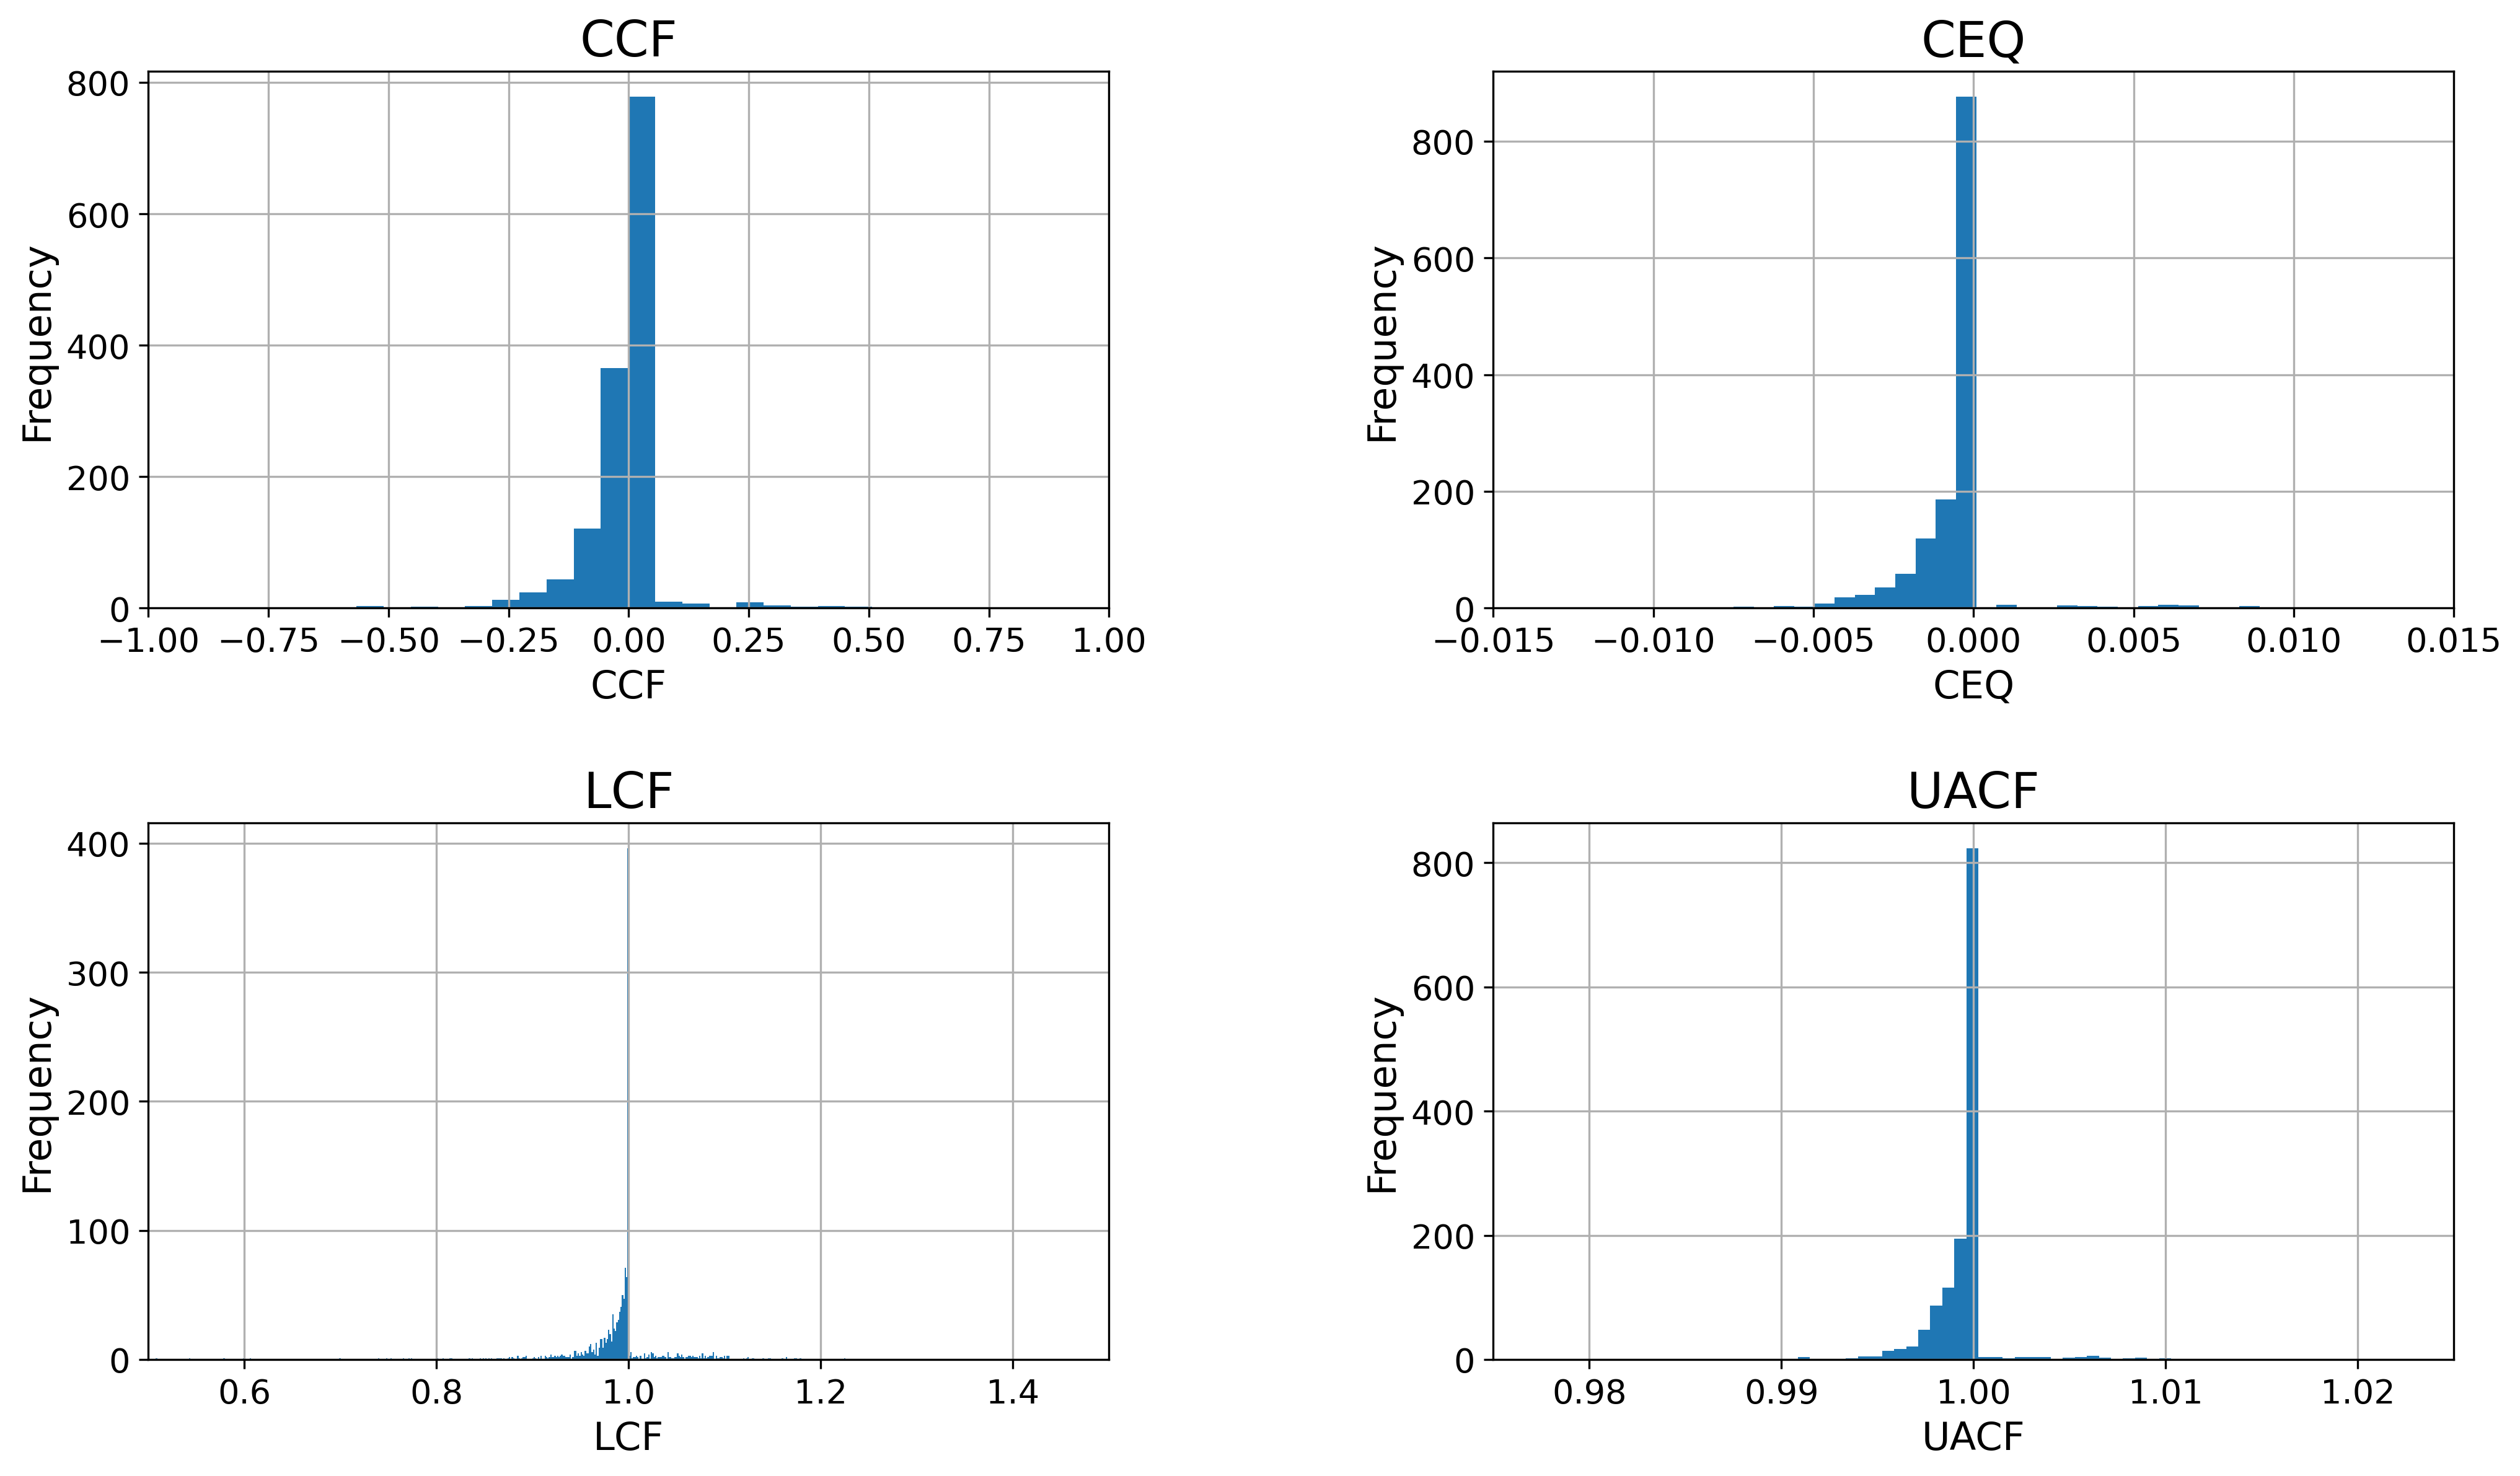

In [10]:
plt.subplots_adjust(hspace=0.4, wspace=0.4)  

plt.subplot(221) 
plt.title('CCF')  
data_default.CCF.hist(bins=500)  
xlim((-1, 1))  
plt.xlabel('CCF', fontsize=15)  
plt.ylabel('Frequency', fontsize=15) 
plt.tick_params(axis='both', labelsize=13) 

plt.subplot(222)  
plt.title('CEQ') 
data_default.CEQ.hist(bins=500)  
xlim((-0.015, 0.015))  
plt.xlabel('CEQ', fontsize=15) 
plt.ylabel('Frequency', fontsize=15)  
plt.tick_params(axis='both', labelsize=13) 

plt.subplot(223)  
plt.title('LCF')  
data_default.LCF.hist(bins=500) 
xlim((0.5, 1.5)) 
plt.xlabel('LCF', fontsize=15) 
plt.ylabel('Frequency', fontsize=15) 
plt.tick_params(axis='both', labelsize=13)  

plt.subplot(224)  
plt.title('UACF') 
data_default.UACF.hist(bins=500) 
xlim((0.975, 1.025)) 
plt.xlabel('UACF', fontsize=15)
plt.ylabel('Frequency', fontsize=15)  
plt.tick_params(axis='both', labelsize=13) 

plt.show() 

In [11]:
model_ols_lcf = smf.ols(formula='LCF ~ cep_time + equity_time+ interest_rate_time +  FICO_orig_time + gdp_time', data=data_default).fit()  

print(model_ols_lcf.summary()) 

                            OLS Regression Results                            
Dep. Variable:                    LCF   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.388
Method:                 Least Squares   F-statistic:                     178.4
Date:                Sun, 17 Aug 2025   Prob (F-statistic):          5.52e-147
Time:                        18:49:02   Log-Likelihood:                 2547.3
No. Observations:                1402   AIC:                            -5083.
Df Residuals:                    1396   BIC:                            -5051.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.8973      0

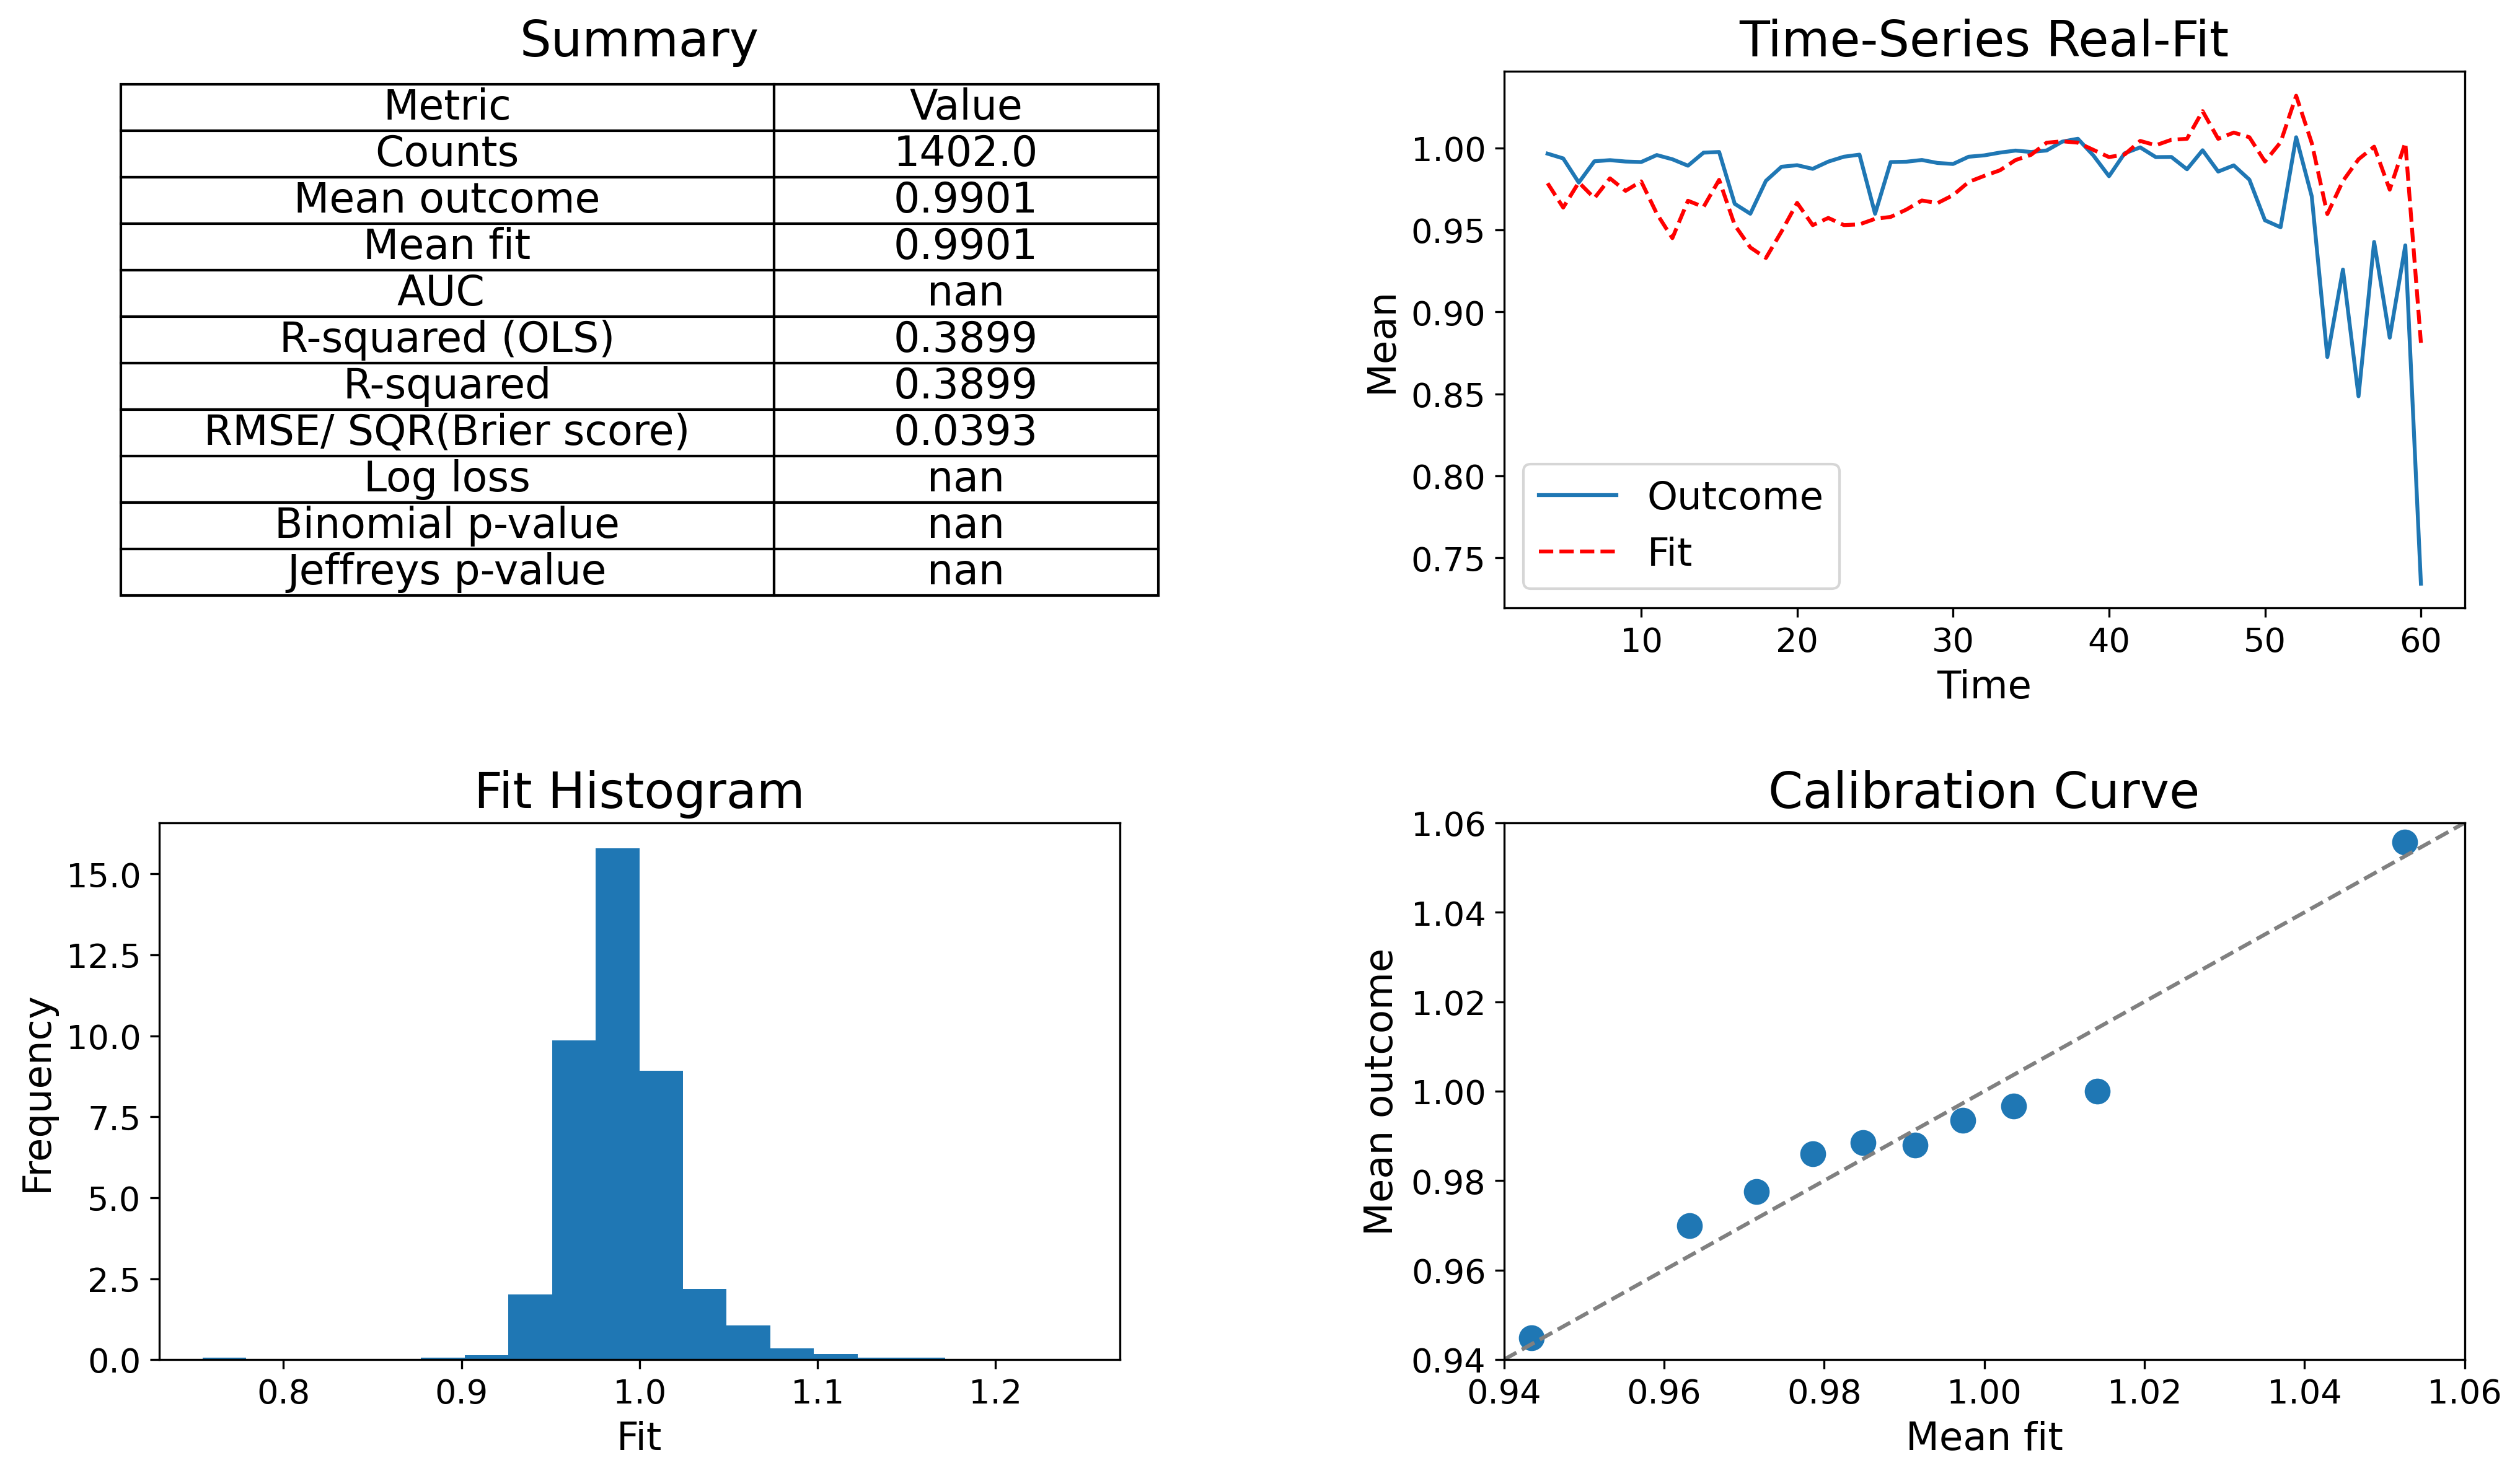

In [12]:
fittedvalues = pd.DataFrame(model_ols_lcf.fittedvalues,columns = ['LCF_fit']) 
data_default = pd.merge(data_default, fittedvalues, right_index=True, left_index=True)  
validation(data_default.LCF_fit, data_default.LCF, data_default.time, continuous=True) 

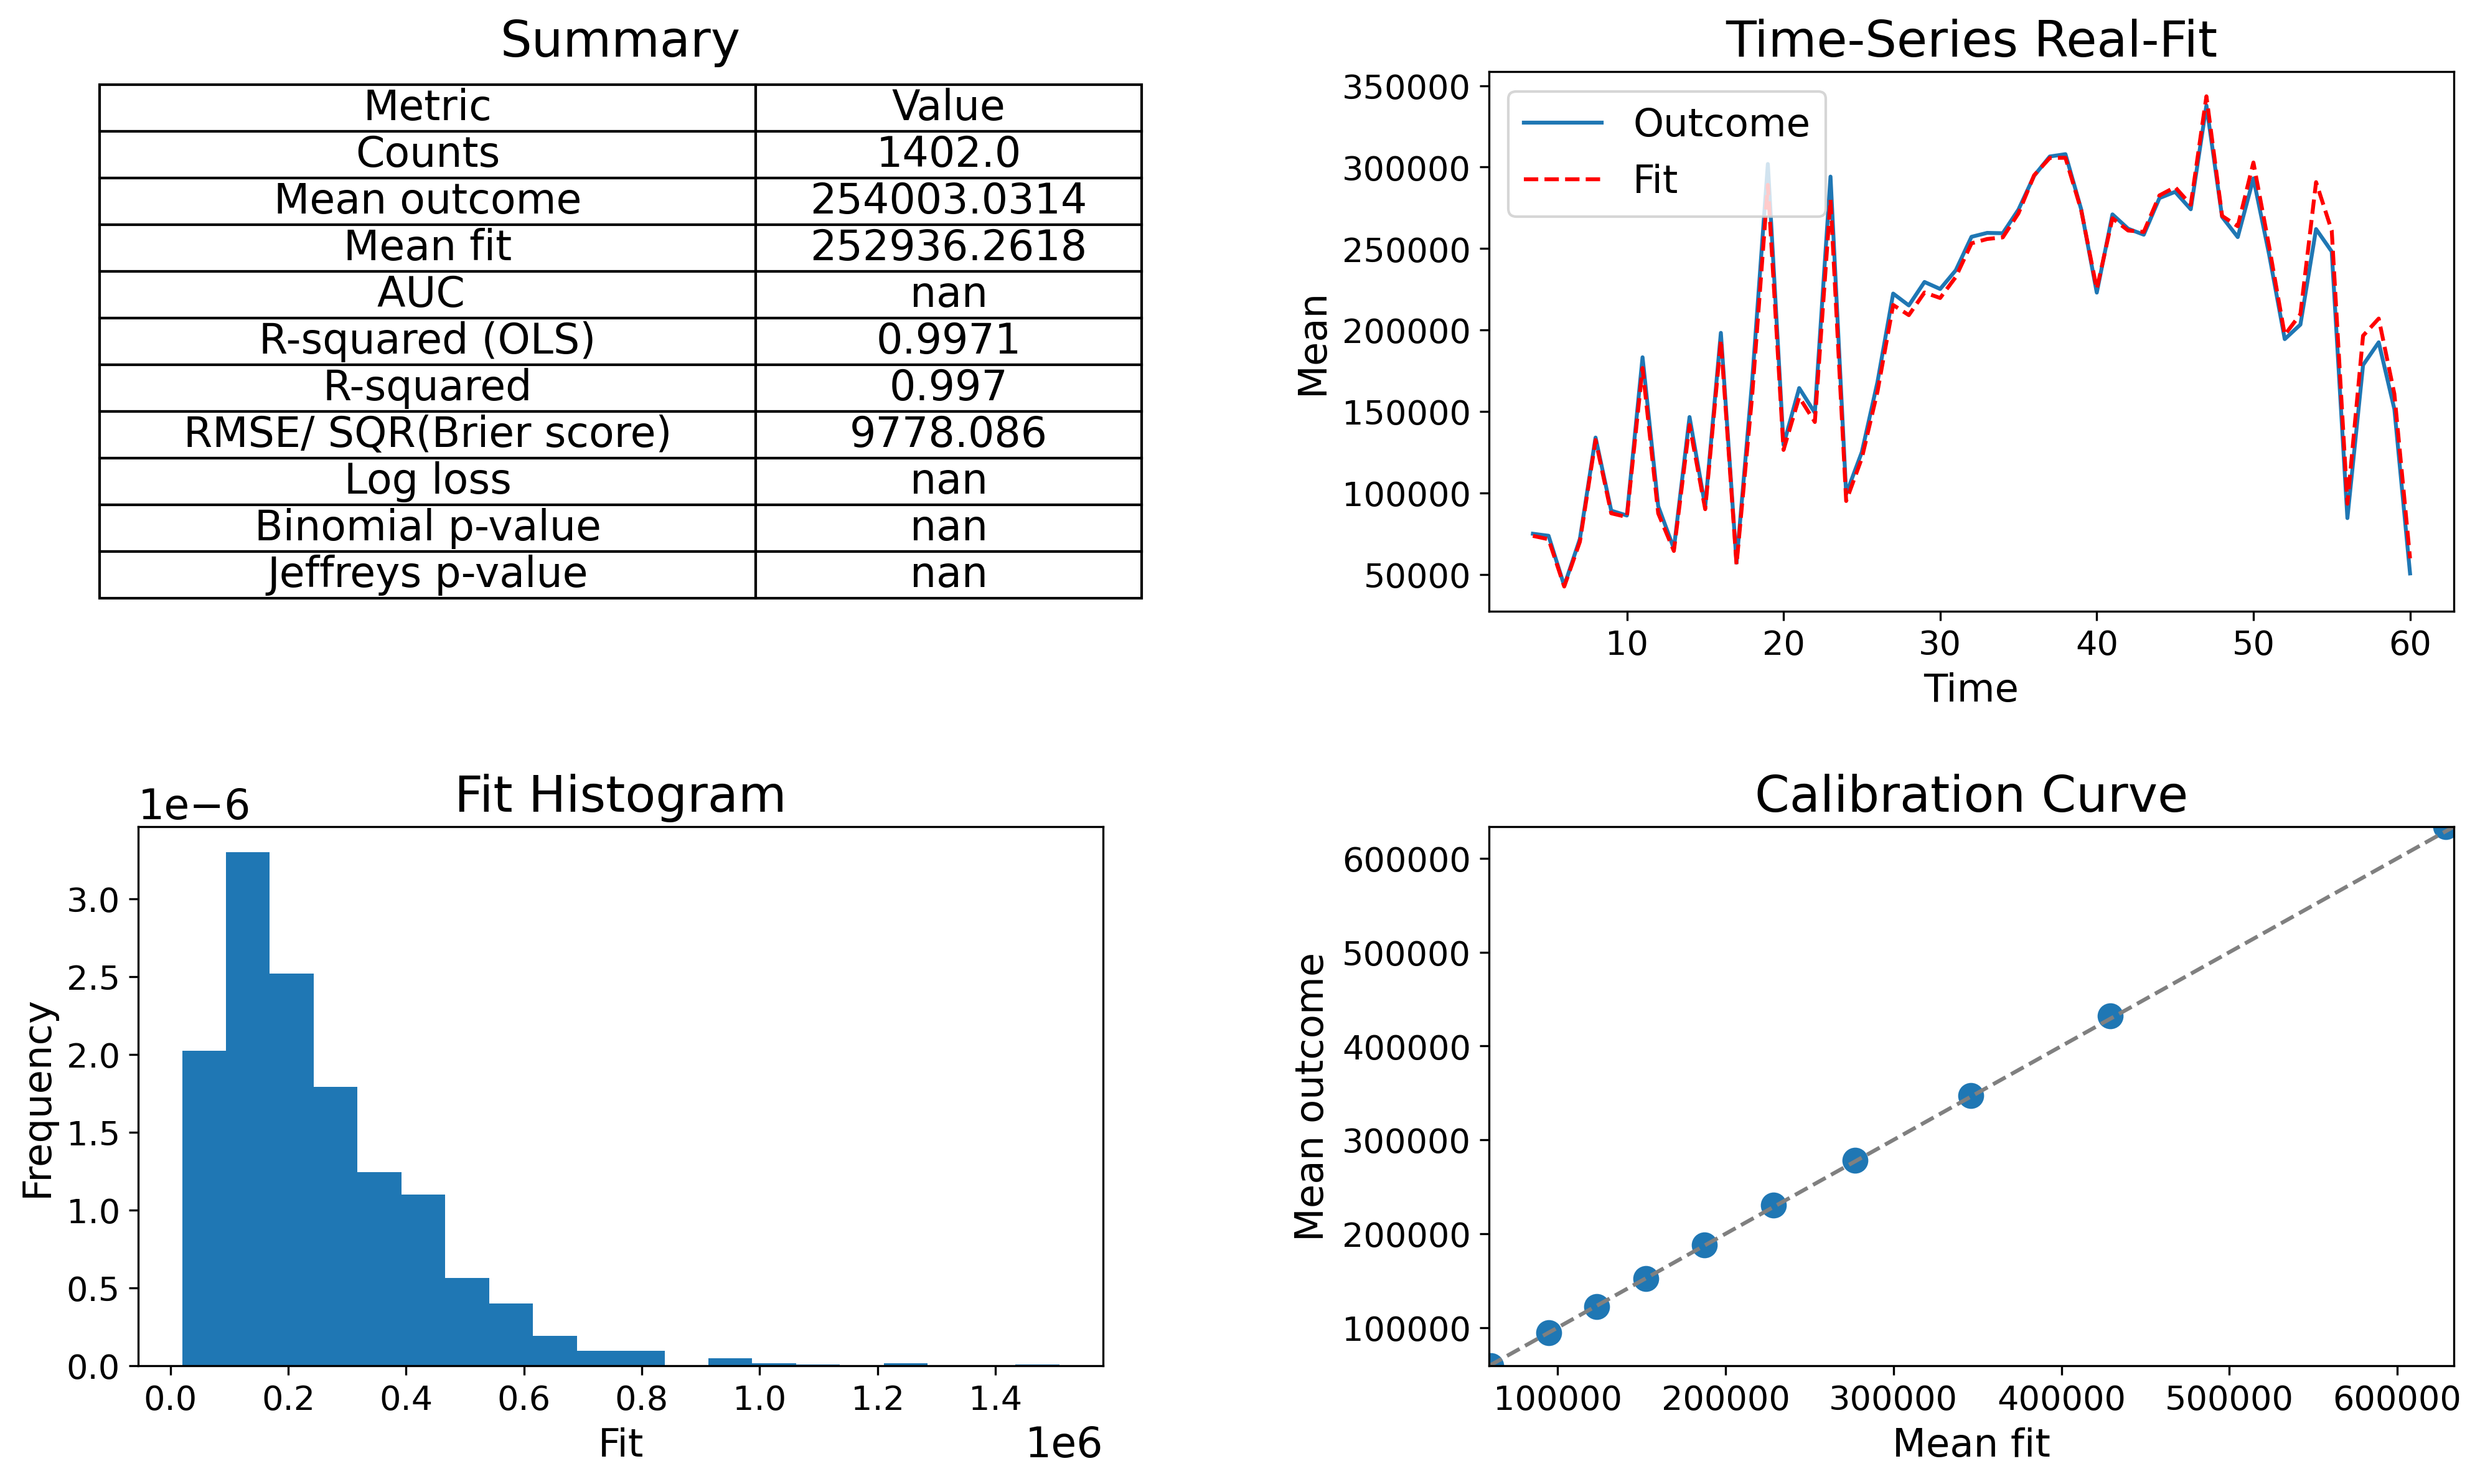

In [14]:
data_default.loc[:,'exposure_fit'] = data_default.loc[:,'LCF_fit']*data_default.loc[:,'limit'] 

validation(data_default.exposure_fit, data_default.balance_time, data_default.time,  continuous=True) 